# Building a Transformer from Scratch

## Learning Objectives

By the end of this notebook, you will:
- Understand **why** Transformers revolutionized deep learning
- Build every component of a Transformer from scratch
- Develop strong intuitions about **self-attention** and **multi-head attention**
- Visualize how information flows through the architecture
- Train a working Transformer on a simple task

## The Journey

We'll build a Transformer **incrementally**, starting from the simplest building blocks:

1. **Problem & Motivation** - Why do we need Transformers?
2. **Tokens & Embeddings** - Converting text to vectors
3. **Positional Encodings** - Giving the model a sense of order
4. **Self-Attention** - The core innovation (single head)
5. **Multi-Head Attention** - Learning multiple patterns simultaneously
6. **Feed-Forward Networks** - Processing each position independently
7. **Layer Normalization & Residuals** - Stabilizing deep networks
8. **Transformer Block** - Combining all components
9. **Complete Architecture** - Building the full model
10. **Training & Visualization** - Seeing it in action

**Our Task**: We'll train a Transformer to predict the next character in a sequence. This is the same task that powers large language models, just at a much smaller scale!

## Part 1: Setup and Motivation

### The Problem with Sequential Processing

Before Transformers, RNNs and LSTMs dominated sequence modeling. They had a fundamental limitation:

**Sequential Processing**: To understand word 100 in a sentence, you had to process words 1-99 first. This meant:
- Slow training (can't parallelize)
- Information bottleneck (distant context gets compressed)
- Gradient flow issues (vanishing gradients)

### The Transformer Solution

Transformers solve this with **self-attention**:
- Process all positions **in parallel**
- Each position can **directly attend** to any other position
- No information bottleneck - direct connections everywhere

Let's build this from scratch!

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
from tqdm import tqdm

# Shared utilities
from aiml_notebooks import (
    get_device, 
    set_seed, 
    create_dataset, 
    create_dataloaders,
    count_parameters
)

# Enable autoreload for library development
%load_ext autoreload
%autoreload 2

# Set random seed for reproducibility
set_seed(42)

# Device setup (use CPU-safe mode for Transformers)
device = get_device(prefer_cpu=True)

# Plotting configuration
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

Using CUDA GPU: NVIDIA GeForce RTX 4090


## Part 2: Data Preparation

We'll use a simple character-level language modeling task. The model will learn to predict the next character given the previous characters.

**Why character-level?**
- Small vocabulary (easy to visualize)
- Clear patterns to learn
- Fast training
- Same principles as word-level or token-level models

In [2]:
# Load dataset using shared factory
full_dataset, train_dataset, val_dataset = create_dataset(
    dataset_id="names",
    splits=[0.9, 0.1]
)

# Extract tokenizer for later use
tokenizer = full_dataset.tokenizer
vocab_size = tokenizer.vocab_size

print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(tokenizer.chars)}")
print(f"\nTraining examples: {len(train_dataset)}")
print(f"Validation examples: {len(val_dataset)}")

# Show a few examples
print("\nExample names:")
for i in range(5):
    x, y = train_dataset[i]
    x_text = tokenizer.decode(x.tolist())
    y_text = tokenizer.decode(y.tolist())
    print(f"  Input:  {x_text}")
    print(f"  Target: {y_text}")
    print()

Vocabulary size: 27
Characters: .abcdefghijklmnopqrstuvwxyz

Training examples: 28829
Validation examples: 3204

Example names:
  Input:  .edison
  Target: edison.

  Input:  .ziyla
  Target: ziyla.

  Input:  .xylia
  Target: xylia.

  Input:  .rhys
  Target: rhys.

  Input:  .zaidyn
  Target: zaidyn.



### Understanding the Task

For each training example:
- **Input**: A sequence of characters (e.g., `.emm`)
- **Target**: The same sequence shifted by one (e.g., `emma.`)

The model learns: Given `.emm`, predict `emma.` (character-by-character)

This is **autoregressive generation** - the foundation of GPT and other language models!

In [3]:
# Create data loaders
BATCH_SIZE = 128

train_loader, val_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0  # Use 0 for simpler debugging
)

print(f"Batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Batches per epoch: 226
Validation batches: 26


## Part 3: Token Embeddings

### From Integers to Vectors

Right now, each character is represented as an integer (e.g., 'a' = 1, 'b' = 2).

**Problem**: Integers don't capture relationships. Is 'c' (3) really the average of 'a' (1) and 'e' (5)? No!

**Solution**: Map each character to a learned vector (embedding) in a continuous space.

- Vocabulary size: 27 characters
- Embedding dimension: Let's use **d_model = 64** (small for learning, but typical values are 512-1024)

Each character becomes a 64-dimensional vector that the model will learn to make meaningful.

In [4]:
# Hyperparameters
d_model = 64  # Embedding dimension
max_seq_len = 20  # Maximum sequence length

# Create embedding layer
embedding = nn.Embedding(vocab_size, d_model)

print(f"Embedding layer shape: {vocab_size} chars -> {d_model} dimensions")
print(f"Total parameters: {vocab_size * d_model:,}")

# Test it
test_indices = torch.tensor([0, 1, 2])  # ['.', 'a', 'b']
test_embeddings = embedding(test_indices)
print(f"\nTest input shape: {test_indices.shape}")
print(f"Test output shape: {test_embeddings.shape}")
print(f"\nFirst character ('.') embedding (first 10 dims): {test_embeddings[0, :10].detach().numpy()}")

Embedding layer shape: 27 chars -> 64 dimensions
Total parameters: 1,728

Test input shape: torch.Size([3])
Test output shape: torch.Size([3, 64])

First character ('.') embedding (first 10 dims): [-0.7319372   0.31248173 -0.23403442 -0.43504637 -0.12446274  0.06835425
  1.9016542   2.068605    1.5030724   0.4063397 ]


### Visualizing Embeddings

Let's visualize the initial (random) embeddings. After training, similar characters will have similar embeddings!

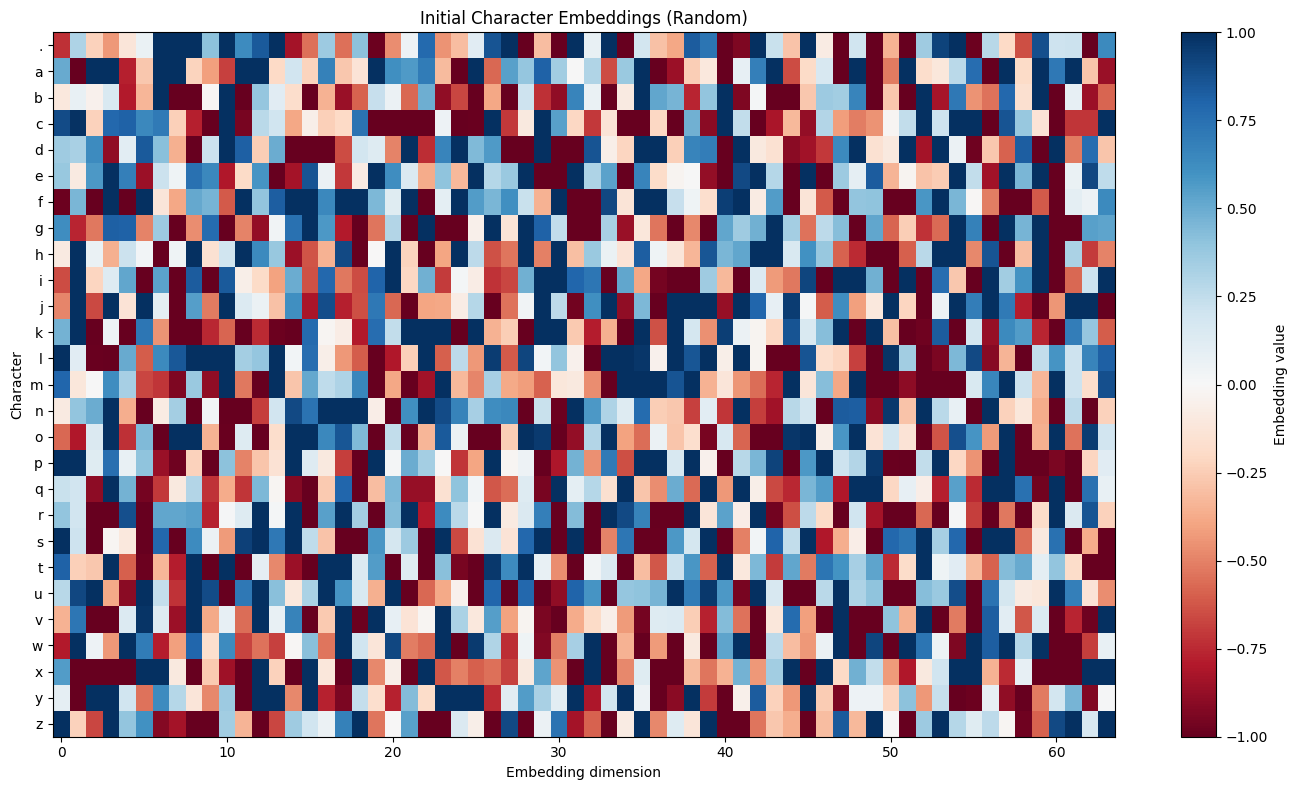

Each row is a character, each column is an embedding dimension.
After training, similar characters will have similar patterns!


In [5]:
# Visualize all character embeddings as a heatmap
all_embeddings = embedding.weight.detach().numpy()  # (vocab_size, d_model)

plt.figure(figsize=(14, 8))
plt.imshow(all_embeddings, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label='Embedding value')
plt.xlabel('Embedding dimension')
plt.ylabel('Character')
plt.title('Initial Character Embeddings (Random)')
plt.yticks(range(vocab_size), tokenizer.chars)
plt.tight_layout()
plt.show()

print("Each row is a character, each column is an embedding dimension.")
print("After training, similar characters will have similar patterns!")

## Part 4: Positional Encodings

### The Problem: No Sense of Order

Embeddings give us meaning, but they don't encode **position**:
- "dog bites man" vs "man bites dog" would look identical!
- We need to tell the model where each token is in the sequence

### The Solution: Positional Encodings

Add position information to the embeddings using sinusoidal functions:

$$
\text{PE}(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$
$$
\text{PE}(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

**Why sinusoids?**
- Different frequencies for different dimensions
- Model can learn to attend to relative positions
- Works for sequences longer than training length

In [6]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encodings."""
    
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)  # (max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)
        
        # Compute div_term: 10000^(2i/d_model) for i = 0, 1, ..., d_model/2
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # Apply sin to even indices, cos to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)  # Even dimensions
        pe[:, 1::2] = torch.cos(position * div_term)  # Odd dimensions
        
        # Register as buffer (not a parameter, but part of state)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        """Add positional encoding to input embeddings.
        
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            (batch, seq_len, d_model)
        """
        seq_len = x.size(1)
        return x + self.pe[:seq_len, :]  # Broadcast across batch

# Create positional encoding
pos_encoding = PositionalEncoding(d_model, max_len=max_seq_len)
print(f"Positional encoding created for max length {max_seq_len}")

Positional encoding created for max length 20


### Visualizing Positional Encodings

Let's see what these encodings look like:

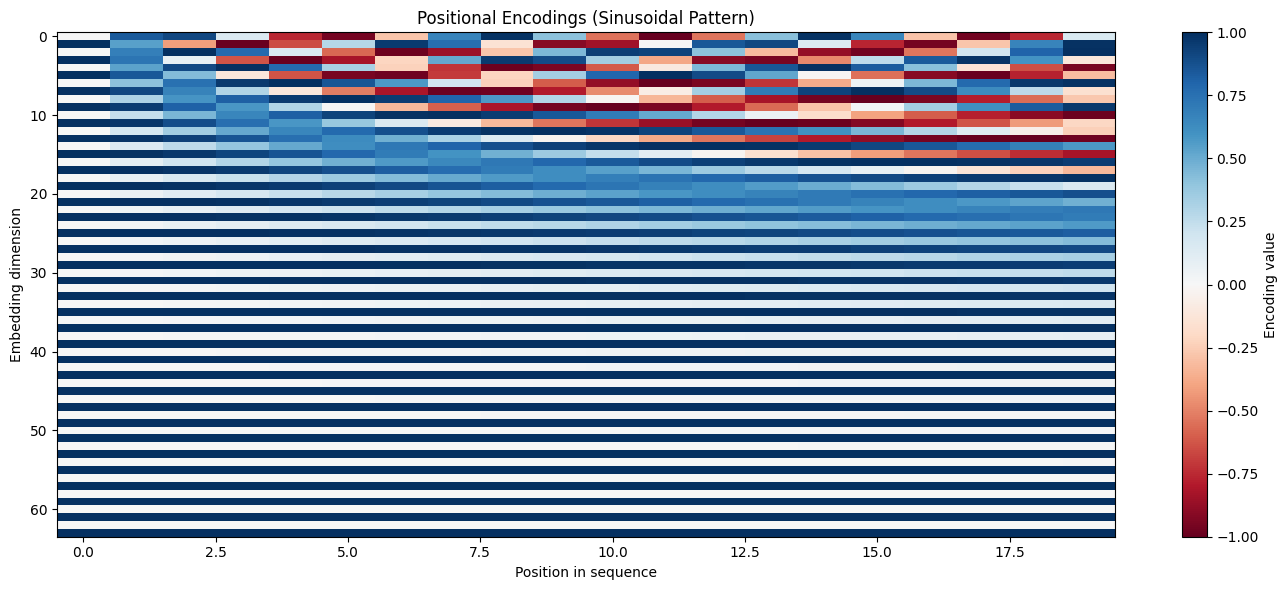

Notice the wave patterns:
- Low dimensions (bottom) have high frequency (change rapidly)
- High dimensions (top) have low frequency (change slowly)
- This gives the model multiple 'time scales' to work with!


In [7]:
# Visualize positional encodings
pe_matrix = pos_encoding.pe[:max_seq_len, :].numpy()

plt.figure(figsize=(14, 6))
plt.imshow(pe_matrix.T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label='Encoding value')
plt.xlabel('Position in sequence')
plt.ylabel('Embedding dimension')
plt.title('Positional Encodings (Sinusoidal Pattern)')
plt.tight_layout()
plt.show()

print("Notice the wave patterns:")
print("- Low dimensions (bottom) have high frequency (change rapidly)")
print("- High dimensions (top) have low frequency (change slowly)")
print("- This gives the model multiple 'time scales' to work with!")

Execute the following code:

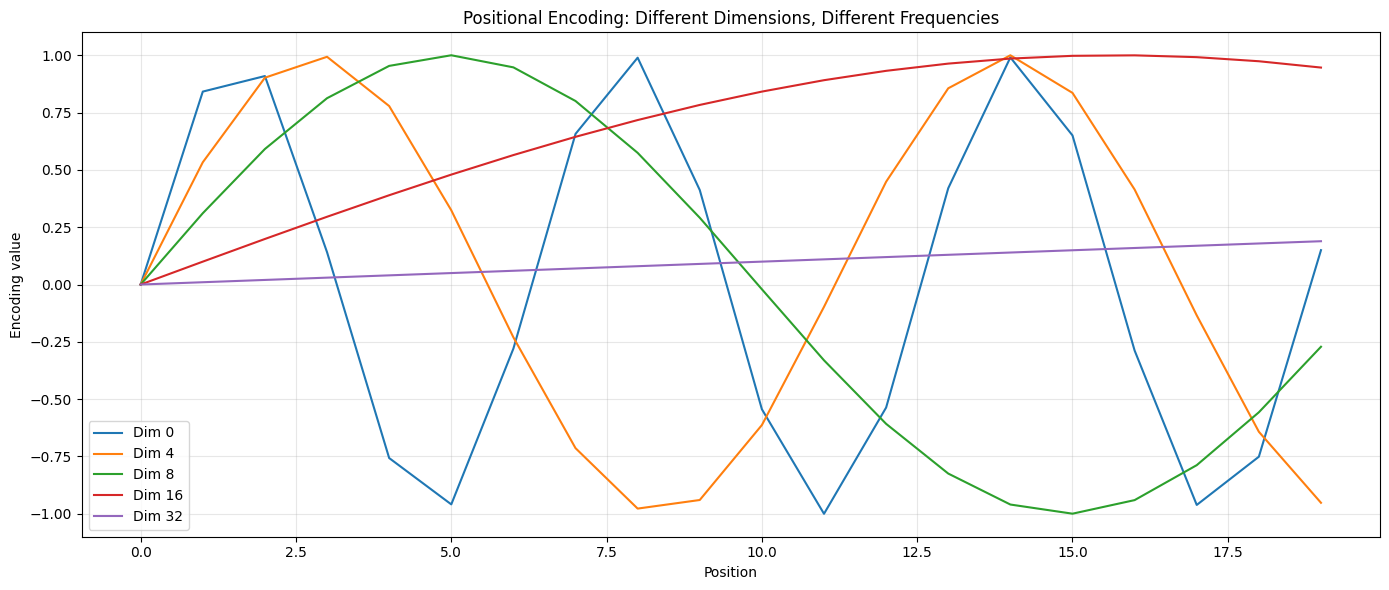

Lower dimensions oscillate faster, higher dimensions oscillate slower.
This helps the model distinguish nearby vs distant positions!


In [8]:
# Plot a few dimensions across positions
plt.figure(figsize=(14, 6))
for i in [0, 4, 8, 16, 32]:
    plt.plot(pe_matrix[:, i], label=f'Dim {i}')
plt.xlabel('Position')
plt.ylabel('Encoding value')
plt.title('Positional Encoding: Different Dimensions, Different Frequencies')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Lower dimensions oscillate faster, higher dimensions oscillate slower.")
print("This helps the model distinguish nearby vs distant positions!")

### Reflection Question

**Q**: Why add positional encodings instead of concatenating them?

**A**: Adding preserves the embedding dimension and allows the model to learn how to combine position and content information. It's simpler and works better in practice!

## Part 5: Self-Attention (Single Head)

### The Core Innovation

Self-attention is the heart of Transformers. It allows each position to **look at all other positions** and decide what's relevant.

### The Intuition

Imagine you're reading: "The animal didn't cross the street because **it** was too tired."

- What does "it" refer to?
- Your brain **attends** back to "animal" (not "street")
- Self-attention does this automatically!

### The Mechanism (Simplified)

For each position:
1. **Query**: What am I looking for?
2. **Key**: What do I contain?
3. **Value**: What information do I offer?

Compute attention: How much should position i attend to position j?

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

In [9]:
class SingleHeadAttention(nn.Module):
    """Single-head self-attention."""
    
    def __init__(self, d_model, d_k):
        """
        Args:
            d_model: Input/output dimension
            d_k: Query/Key dimension (usually d_model // num_heads)
        """
        super().__init__()
        self.d_k = d_k
        
        # Linear projections for Q, K, V
        self.query = nn.Linear(d_model, d_k)
        self.key = nn.Linear(d_model, d_k)
        self.value = nn.Linear(d_model, d_k)
        
    def forward(self, x, mask=None, return_attention=False):
        """
        Args:
            x: (batch, seq_len, d_model)
            mask: (batch, seq_len, seq_len) - True where attention is not allowed
            return_attention: If True, return attention weights
        Returns:
            output: (batch, seq_len, d_k)
            attention_weights: (batch, seq_len, seq_len) if return_attention=True
        """
        # Linear projections
        Q = self.query(x)  # (batch, seq_len, d_k)
        K = self.key(x)    # (batch, seq_len, d_k)
        V = self.value(x)  # (batch, seq_len, d_k)
        
        # Compute attention scores: Q * K^T / sqrt(d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (batch, seq_len, seq_len)
        
        # Apply mask (set masked positions to -inf before softmax)
        if mask is not None:
            scores = scores.masked_fill(mask, -1e9)
        
        # Apply softmax to get attention weights
        attention_weights = F.softmax(scores, dim=-1)  # (batch, seq_len, seq_len)
        
        # Apply attention weights to values
        output = torch.matmul(attention_weights, V)  # (batch, seq_len, d_k)
        
        if return_attention:
            return output, attention_weights
        return output

# Create single-head attention
d_k = d_model  # For single head, use full dimension
single_attention = SingleHeadAttention(d_model, d_k)
print(f"Single-head attention: {d_model} -> {d_k}")

Single-head attention: 64 -> 64


### Testing Self-Attention

Let's see what attention patterns look like for a sample sequence!

Input shape: torch.Size([1, 11, 64])
Output shape: torch.Size([1, 11, 64])
Attention weights shape: torch.Size([1, 11, 11])


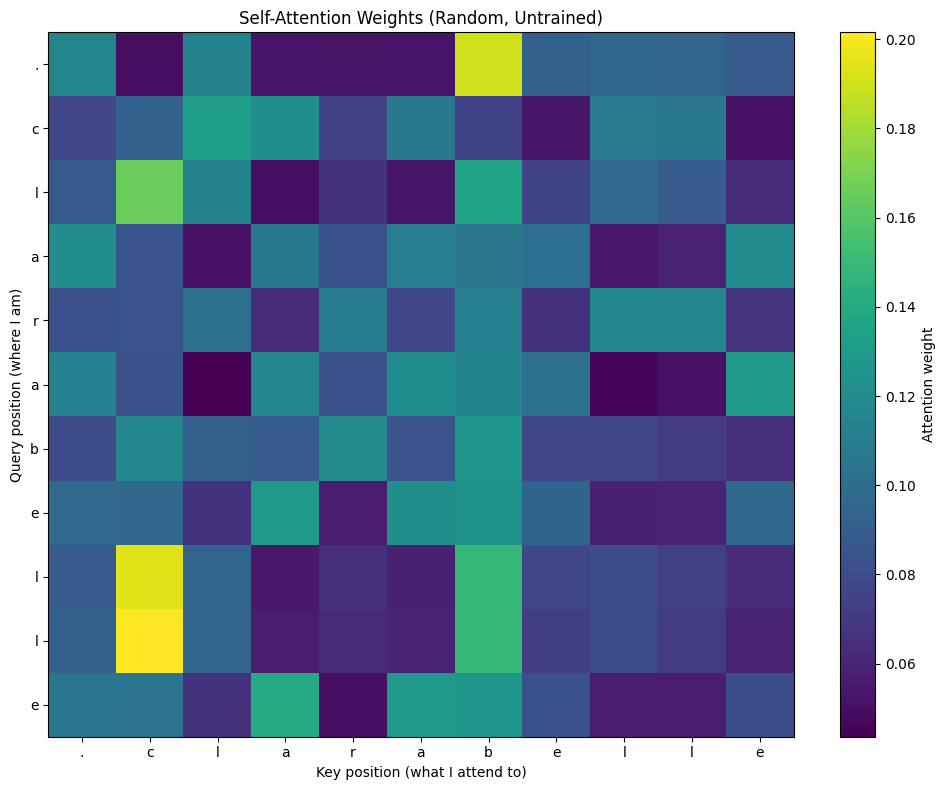


Reading the heatmap:
- Each ROW shows: When I'm at position i, where do I attend?
- Each COLUMN shows: Which positions attend to position j?
- Brighter = more attention


In [10]:
# Get a sample batch
sample_x, _ = next(iter(train_loader))
sample_x = sample_x[:1]  # Take first example

# Get embeddings and add positional encoding
sample_embedded = embedding(sample_x)  # (1, seq_len, d_model)
sample_embedded = pos_encoding(sample_embedded)

# Apply attention
output, attention_weights = single_attention(sample_embedded, return_attention=True)

print(f"Input shape: {sample_embedded.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {attention_weights.shape}")

# Visualize attention weights
attn = attention_weights[0].detach().numpy()  # (seq_len, seq_len)
seq_len = sample_x.shape[1]
chars = [tokenizer.decode_char(idx.item()) for idx in sample_x[0]]

plt.figure(figsize=(10, 8))
plt.imshow(attn, cmap='viridis', aspect='auto')
plt.colorbar(label='Attention weight')
plt.xlabel('Key position (what I attend to)')
plt.ylabel('Query position (where I am)')
plt.title('Self-Attention Weights (Random, Untrained)')
plt.xticks(range(seq_len), chars)
plt.yticks(range(seq_len), chars)
plt.tight_layout()
plt.show()

print("\nReading the heatmap:")
print("- Each ROW shows: When I'm at position i, where do I attend?")
print("- Each COLUMN shows: Which positions attend to position j?")
print("- Brighter = more attention")

### Causal Masking

For autoregressive generation (predicting the next token), we need **causal masking**:
- Position i can only attend to positions ≤ i
- This prevents "looking into the future"

Let's add a mask!

Causal mask:
[[0 1 1 1 1 1 1 1 1 1]
 [0 0 1 1 1 1 1 1 1 1]
 [0 0 0 1 1 1 1 1 1 1]
 [0 0 0 0 1 1 1 1 1 1]
 [0 0 0 0 0 1 1 1 1 1]
 [0 0 0 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 1 1]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0]]

0 = can attend, 1 = masked (cannot attend)


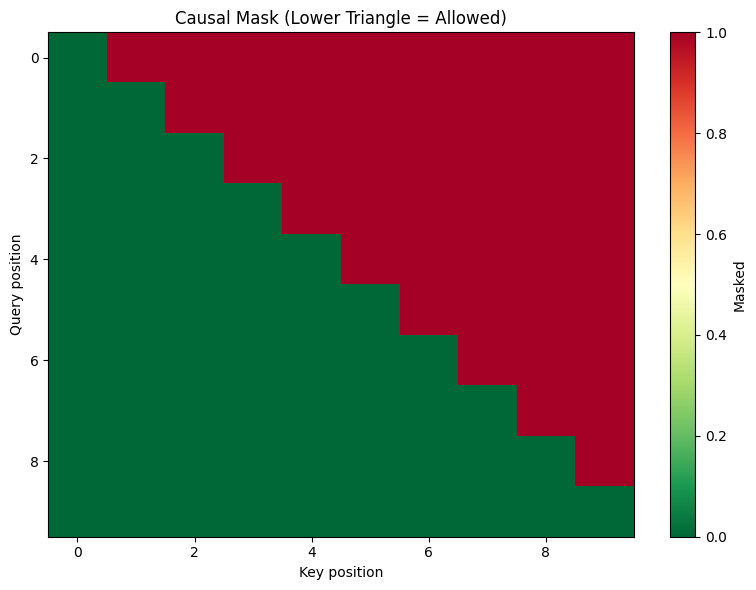

In [11]:
def create_causal_mask(seq_len):
    """Create a causal mask for autoregressive attention.
    
    Returns:
        mask: (seq_len, seq_len) where True = masked (no attention)
    """
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
    return mask

# Create and visualize mask
mask = create_causal_mask(10)
print("Causal mask:")
print(mask.int().numpy())
print("\n0 = can attend, 1 = masked (cannot attend)")

plt.figure(figsize=(8, 6))
plt.imshow(mask.numpy(), cmap='RdYlGn_r', aspect='auto')
plt.colorbar(label='Masked')
plt.xlabel('Key position')
plt.ylabel('Query position')
plt.title('Causal Mask (Lower Triangle = Allowed)')
plt.tight_layout()
plt.show()

Execute the following code:

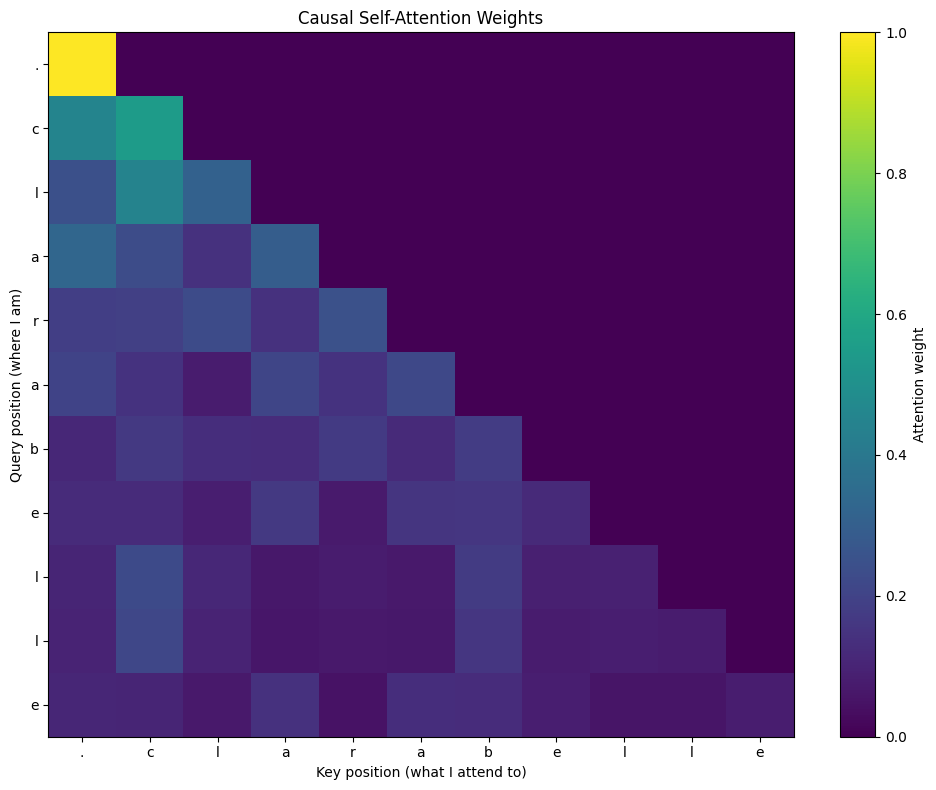

Notice: Upper triangle is now zero!
Each position can only attend to itself and previous positions.


In [12]:
# Apply attention with causal mask
mask = create_causal_mask(seq_len)
output_masked, attention_weights_masked = single_attention(
    sample_embedded, 
    mask=mask, 
    return_attention=True
)

# Visualize masked attention
attn_masked = attention_weights_masked[0].detach().numpy()

plt.figure(figsize=(10, 8))
plt.imshow(attn_masked, cmap='viridis', aspect='auto')
plt.colorbar(label='Attention weight')
plt.xlabel('Key position (what I attend to)')
plt.ylabel('Query position (where I am)')
plt.title('Causal Self-Attention Weights')
plt.xticks(range(seq_len), chars)
plt.yticks(range(seq_len), chars)
plt.tight_layout()
plt.show()

print("Notice: Upper triangle is now zero!")
print("Each position can only attend to itself and previous positions.")

### Reflection Questions

**Q1**: Why divide by sqrt(d_k) in the attention scores?

**A**: Without scaling, dot products grow with dimension size, making softmax very "peaky" (almost one-hot). This makes gradients very small. Scaling keeps values in a reasonable range.

**Q2**: What does a row in the attention matrix represent?

**A**: A row shows the attention distribution for one query position - where that position "looks" in the sequence.

## Part 6: Multi-Head Attention

### The Limitation of Single-Head Attention

A single attention head can only learn **one way** to relate positions. But language has many relationships:
- Syntactic (subject-verb agreement)
- Semantic ("it" refers to "animal")
- Positional (nearby words)

### The Solution: Multiple Heads

Run several attention mechanisms in parallel:
- Each head learns different patterns
- Split d_model across heads: d_k = d_model / num_heads
- Concatenate outputs and project back

**Example**: With d_model=64 and 4 heads, each head works in 16 dimensions.

In [13]:
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention."""
    
    def __init__(self, d_model, num_heads):
        """
        Args:
            d_model: Input/output dimension
            num_heads: Number of attention heads
        """
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension per head
        
        # Linear projections for all heads (combined)
        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        
        # Output projection
        self.out = nn.Linear(d_model, d_model)
        
    def forward(self, x, mask=None, return_attention=False):
        """
        Args:
            x: (batch, seq_len, d_model)
            mask: (seq_len, seq_len) - True where attention is not allowed
            return_attention: If True, return attention weights
        Returns:
            output: (batch, seq_len, d_model)
            attention_weights: (batch, num_heads, seq_len, seq_len) if return_attention=True
        """
        batch_size, seq_len, _ = x.shape
        
        # Linear projections and split into heads
        # (batch, seq_len, d_model) -> (batch, seq_len, num_heads, d_k) -> (batch, num_heads, seq_len, d_k)
        Q = self.query(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.key(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.value(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        
        # Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (batch, num_heads, seq_len, seq_len)
        
        # Apply mask
        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(0).unsqueeze(0), -1e9)
        
        # Apply softmax
        attention_weights = F.softmax(scores, dim=-1)  # (batch, num_heads, seq_len, seq_len)
        
        # Apply attention to values
        attention_output = torch.matmul(attention_weights, V)  # (batch, num_heads, seq_len, d_k)
        
        # Concatenate heads and project
        # (batch, num_heads, seq_len, d_k) -> (batch, seq_len, num_heads, d_k) -> (batch, seq_len, d_model)
        attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        
        # Final projection
        output = self.out(attention_output)
        
        if return_attention:
            return output, attention_weights
        return output

# Create multi-head attention
num_heads = 4
multi_attention = MultiHeadAttention(d_model, num_heads)
print(f"Multi-head attention: {num_heads} heads, {d_model // num_heads} dims each")
print(f"Parameters: {sum(p.numel() for p in multi_attention.parameters()):,}")

Multi-head attention: 4 heads, 16 dims each
Parameters: 16,640


### Visualizing Multiple Attention Heads

Let's see what different heads learn to attend to!

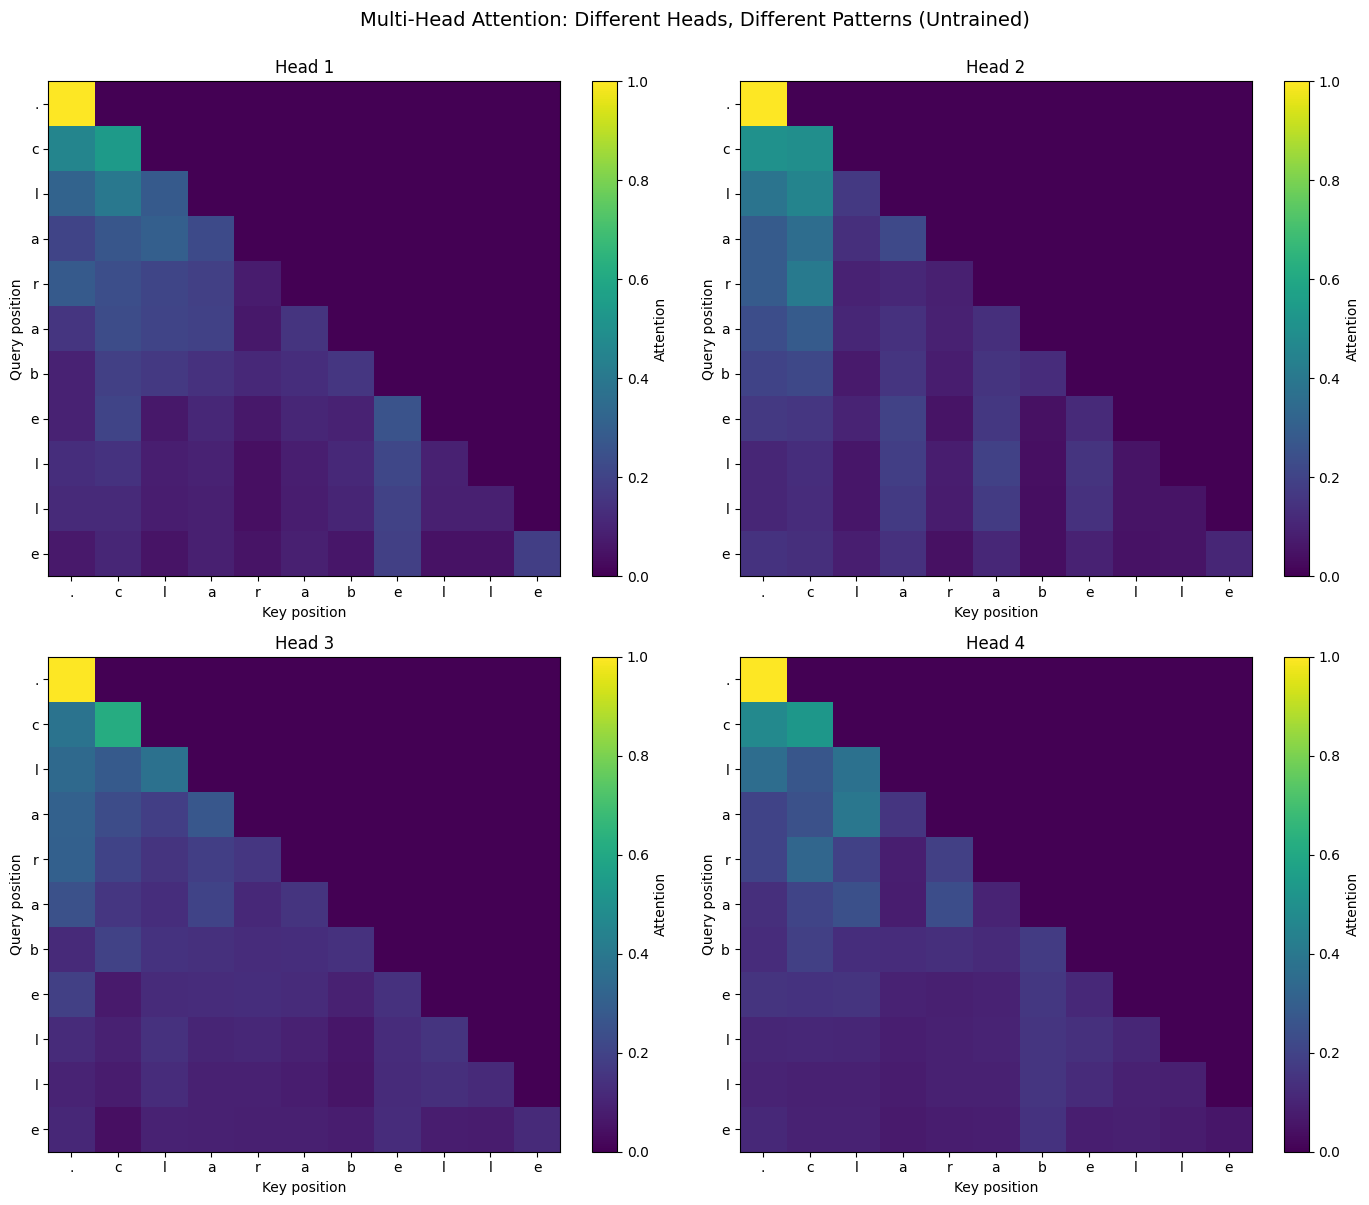

Notice: Even untrained, each head has slightly different patterns!
After training, they'll specialize in different relationships.


In [14]:
# Apply multi-head attention
mask = create_causal_mask(seq_len)
output_multi, attention_weights_multi = multi_attention(
    sample_embedded,
    mask=mask,
    return_attention=True
)

# Visualize all heads
attn_multi = attention_weights_multi[0].detach().numpy()  # (num_heads, seq_len, seq_len)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for head_idx in range(num_heads):
    ax = axes[head_idx]
    im = ax.imshow(attn_multi[head_idx], cmap='viridis', aspect='auto')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
    ax.set_title(f'Head {head_idx + 1}')
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(chars, rotation=0)
    ax.set_yticklabels(chars)
    plt.colorbar(im, ax=ax, label='Attention')

plt.suptitle('Multi-Head Attention: Different Heads, Different Patterns (Untrained)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("Notice: Even untrained, each head has slightly different patterns!")
print("After training, they'll specialize in different relationships.")

### Reflection Question

**Q**: Why split d_model across heads instead of giving each head the full dimension?

**A**: Computational efficiency! With h heads and d_k = d_model/h:
- Total parameters stay the same
- Computation stays the same
- But we get h different "perspectives" on the data!

## Part 7: Feed-Forward Networks

### Why We Need Them

Attention is great at **aggregating information** across positions, but it's linear!

Feed-forward networks add:
- **Non-linearity** (via activation functions)
- **Position-wise processing** (each position independently)
- **Capacity** to learn complex transformations

### The Architecture

$$
\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2
$$

Typically:
- Expand: d_model → 4 * d_model (gives network capacity)
- Apply ReLU
- Contract: 4 * d_model → d_model

In [15]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network."""
    
    def __init__(self, d_model, d_ff, dropout=0.1):
        """
        Args:
            d_model: Input/output dimension
            d_ff: Hidden dimension (typically 4 * d_model)
            dropout: Dropout probability
        """
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            (batch, seq_len, d_model)
        """
        # Expand, activate, contract
        x = self.linear1(x)      # (batch, seq_len, d_ff)
        x = F.relu(x)            # Non-linearity
        x = self.dropout(x)
        x = self.linear2(x)      # (batch, seq_len, d_model)
        return x

# Create feed-forward network
d_ff = 4 * d_model  # Standard expansion factor
ffn = FeedForward(d_model, d_ff)
print(f"Feed-forward: {d_model} -> {d_ff} -> {d_model}")
print(f"Parameters: {sum(p.numel() for p in ffn.parameters()):,}")

# Test it
test_output = ffn(sample_embedded)
print(f"\nInput shape: {sample_embedded.shape}")
print(f"Output shape: {test_output.shape}")

Feed-forward: 64 -> 256 -> 64
Parameters: 33,088

Input shape: torch.Size([1, 11, 64])
Output shape: torch.Size([1, 11, 64])


## Part 8: Layer Normalization and Residual Connections

### The Problem: Deep Networks are Hard to Train

As we stack layers:
- Gradients can vanish or explode
- Activations can become too large or too small
- Training becomes unstable

### Solution 1: Residual Connections

Instead of `x = Layer(x)`, use `x = x + Layer(x)`

**Benefits:**
- Gradients flow directly through the residual path
- Network can learn identity function (if needed)
- Much easier to train deep networks

### Solution 2: Layer Normalization

Normalize activations across the feature dimension:

$$
\text{LayerNorm}(x) = \gamma \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta
$$

**Benefits:**
- Stabilizes training
- Reduces internal covariate shift
- Allows higher learning rates

In [16]:
# Layer normalization is built into PyTorch
layer_norm = nn.LayerNorm(d_model)

# Test normalization
print("Before normalization:")
print(f"  Mean: {sample_embedded.mean():.4f}")
print(f"  Std:  {sample_embedded.std():.4f}")
print(f"  Min:  {sample_embedded.min():.4f}")
print(f"  Max:  {sample_embedded.max():.4f}")

normalized = layer_norm(sample_embedded)

print("\nAfter normalization:")
print(f"  Mean: {normalized.mean():.4f}")
print(f"  Std:  {normalized.std():.4f}")
print(f"  Min:  {normalized.min():.4f}")
print(f"  Max:  {normalized.max():.4f}")

print("\nNormalization brings values to a standard range!")

Before normalization:
  Mean: 0.5287
  Std:  1.1637
  Min:  -2.6689
  Max:  3.8341

After normalization:
  Mean: 0.0000
  Std:  1.0007
  Min:  -2.9413
  Max:  2.6277

Normalization brings values to a standard range!


## Part 9: Transformer Block

### Putting It All Together

A Transformer block combines:
1. Multi-head attention (with residual + norm)
2. Feed-forward network (with residual + norm)

The standard architecture:

```
x = x + MultiHeadAttention(LayerNorm(x))
x = x + FeedForward(LayerNorm(x))
```

This is called **Pre-LN** (layer norm before the sub-layer). It's more stable than Post-LN!

In [17]:
class TransformerBlock(nn.Module):
    """Single Transformer block (attention + feed-forward)."""
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        """
        Args:
            d_model: Model dimension
            num_heads: Number of attention heads
            d_ff: Feed-forward hidden dimension
            dropout: Dropout probability
        """
        super().__init__()
        
        # Sub-layers
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        
        # Layer normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        """
        Args:
            x: (batch, seq_len, d_model)
            mask: (seq_len, seq_len)
        Returns:
            (batch, seq_len, d_model)
        """
        # Multi-head attention with residual connection (Pre-LN)
        attn_output = self.attention(self.norm1(x), mask=mask)
        x = x + self.dropout(attn_output)
        
        # Feed-forward with residual connection (Pre-LN)
        ff_output = self.feed_forward(self.norm2(x))
        x = x + self.dropout(ff_output)
        
        return x

# Create transformer block
transformer_block = TransformerBlock(d_model, num_heads, d_ff)
print(f"Transformer block created")
print(f"Parameters: {sum(p.numel() for p in transformer_block.parameters()):,}")

# Test it
mask = create_causal_mask(seq_len)
block_output = transformer_block(sample_embedded, mask=mask)
print(f"\nInput shape:  {sample_embedded.shape}")
print(f"Output shape: {block_output.shape}")
print("Shape preserved - can stack multiple blocks!")

Transformer block created
Parameters: 49,984

Input shape:  torch.Size([1, 11, 64])
Output shape: torch.Size([1, 11, 64])
Shape preserved - can stack multiple blocks!


## Part 10: Complete Transformer Model

### The Full Architecture

Now we stack everything:

1. **Input**: Token IDs
2. **Embedding**: Convert to vectors
3. **Positional Encoding**: Add position information
4. **Transformer Blocks**: Stack N blocks
5. **Output Projection**: Map to vocabulary logits

This is a **decoder-only** Transformer (like GPT), perfect for autoregressive generation!

In [18]:
class Transformer(nn.Module):
    """Complete Transformer model for autoregressive generation."""
    
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, 
                 max_seq_len=1000, dropout=0.1):
        """
        Args:
            vocab_size: Size of vocabulary
            d_model: Model dimension
            num_heads: Number of attention heads
            num_layers: Number of transformer blocks
            d_ff: Feed-forward hidden dimension
            max_seq_len: Maximum sequence length
            dropout: Dropout probability
        """
        super().__init__()
        
        # Input embedding
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len)
        
        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Output projection
        self.norm = nn.LayerNorm(d_model)
        self.output = nn.Linear(d_model, vocab_size)
        
        self.dropout = nn.Dropout(dropout)
        
        # Initialize parameters
        self._init_parameters()
        
    def _init_parameters(self):
        """Initialize parameters with Xavier uniform."""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, x, mask=None):
        """
        Args:
            x: (batch, seq_len) - token IDs
            mask: (seq_len, seq_len) - attention mask
        Returns:
            logits: (batch, seq_len, vocab_size)
        """
        # Embed and add positional encoding
        x = self.embedding(x)  # (batch, seq_len, d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        
        # Apply transformer blocks
        for block in self.blocks:
            x = block(x, mask=mask)
        
        # Output projection
        x = self.norm(x)
        logits = self.output(x)  # (batch, seq_len, vocab_size)
        
        return logits
    
    def generate(self, idx, max_new_tokens, temperature=1.0):
        """
        Generate new tokens autoregressively.
        
        Args:
            idx: (batch, seq_len) - initial context
            max_new_tokens: Number of tokens to generate
            temperature: Sampling temperature (higher = more random)
        Returns:
            (batch, seq_len + max_new_tokens) - generated sequence
        """
        for _ in range(max_new_tokens):
            # Get logits for current sequence
            seq_len = idx.size(1)
            mask = create_causal_mask(seq_len).to(idx.device)
            logits = self(idx, mask=mask)  # (batch, seq_len, vocab_size)
            
            # Focus on last position
            logits = logits[:, -1, :] / temperature  # (batch, vocab_size)
            
            # Sample from distribution
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch, 1)
            
            # Append to sequence
            idx = torch.cat([idx, idx_next], dim=1)  # (batch, seq_len + 1)
        
        return idx

# Create model
num_layers = 4
model = Transformer(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    d_ff=d_ff,
    max_seq_len=max_seq_len,
    dropout=0.1
).to(device)

print(f"Transformer Model:")
print(f"  Layers: {num_layers}")
print(f"  d_model: {d_model}")
print(f"  Heads: {num_heads}")
print(f"  d_ff: {d_ff}")
print(f"  Total parameters: {count_parameters(model):,}")

Transformer Model:
  Layers: 4
  d_model: 64
  Heads: 4
  d_ff: 256
  Total parameters: 203,547


### Testing the Model

Let's verify the model works with our data!

In [19]:
# Test forward pass
sample_x, sample_y = next(iter(train_loader))
sample_x = sample_x.to(device)
sample_y = sample_y.to(device)

# Create mask
seq_len = sample_x.size(1)
mask = create_causal_mask(seq_len).to(device)

# Forward pass
with torch.no_grad():
    logits = model(sample_x, mask=mask)

print(f"Input shape:  {sample_x.shape}")
print(f"Output shape: {logits.shape}")
print(f"Expected:     (batch={BATCH_SIZE}, seq_len={seq_len}, vocab_size={vocab_size})")
print("\n✓ Model works!")

Input shape:  torch.Size([128, 12])
Output shape: torch.Size([128, 12, 27])
Expected:     (batch=128, seq_len=12, vocab_size=27)

✓ Model works!


## Part 11: Training

### Training Setup

We'll train the model to predict the next character using:
- **Loss**: Cross-entropy (standard for classification)
- **Optimizer**: AdamW (Adam with weight decay)
- **Learning Rate**: 3e-4 (standard for Transformers)

The training loop:
1. Get batch of sequences
2. Forward pass with causal mask
3. Compute loss
4. Backward pass
5. Update parameters

In [20]:
# Training hyperparameters
learning_rate = 3e-4
num_epochs = 5
grad_clip = 1.0  # Gradient clipping for stability

# Optimizer and loss
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

print(f"Training configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Batches per epoch: {len(train_loader)}")
print(f"  Total steps: {num_epochs * len(train_loader)}")

Training configuration:
  Epochs: 5
  Learning rate: 0.0003
  Batch size: 128
  Batches per epoch: 226
  Total steps: 1130


Execute the following code:

In [21]:
def train_epoch(model, train_loader, optimizer, criterion, device, grad_clip=1.0):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    pbar = tqdm(train_loader, desc='Training')
    for batch_idx, (x, y) in enumerate(pbar):
        x, y = x.to(device), y.to(device)
        
        # Create causal mask
        seq_len = x.size(1)
        mask = create_causal_mask(seq_len).to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits = model(x, mask=mask)  # (batch, seq_len, vocab_size)
        
        # Compute loss
        # Reshape for cross-entropy: (batch * seq_len, vocab_size)
        loss = criterion(logits.view(-1, vocab_size), y.view(-1))
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        
        # Update parameters
        optimizer.step()
        
        # Track loss
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(train_loader)

def evaluate(model, val_loader, criterion, device):
    """Evaluate on validation set."""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            
            # Create causal mask
            seq_len = x.size(1)
            mask = create_causal_mask(seq_len).to(device)
            
            # Forward pass
            logits = model(x, mask=mask)
            
            # Compute loss
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))
            total_loss += loss.item()
    
    return total_loss / len(val_loader)

print("Training functions defined!")

Training functions defined!


Execute the following code:

In [22]:
# Training loop
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device, grad_clip)
    train_losses.append(train_loss)
    
    # Evaluate
    val_loss = evaluate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("\n✓ Training complete!")


Epoch 1/5


Training:   0%|          | 0/226 [00:00<?, ?it/s]

Training:   0%|          | 0/226 [00:00<?, ?it/s, loss=3.6944]

Training:   0%|          | 1/226 [00:00<00:43,  5.17it/s, loss=3.6944]

Training:   0%|          | 1/226 [00:00<00:43,  5.17it/s, loss=3.3678]

...

Training:  99%|█████████▉| 224/226 [00:02<00:00, 108.10it/s, loss=2.2500]

Training:  99%|█████████▉| 224/226 [00:02<00:00, 108.10it/s, loss=2.2842]

Training:  99%|█████████▉| 224/226 [00:02<00:00, 108.10it/s, loss=2.3963]

Training: 100%|██████████| 226/226 [00:02<00:00, 103.08it/s, loss=2.3963]

Train Loss: 2.2719 | Val Loss: 2.2023

✓ Training complete!


### Visualizing Training Progress

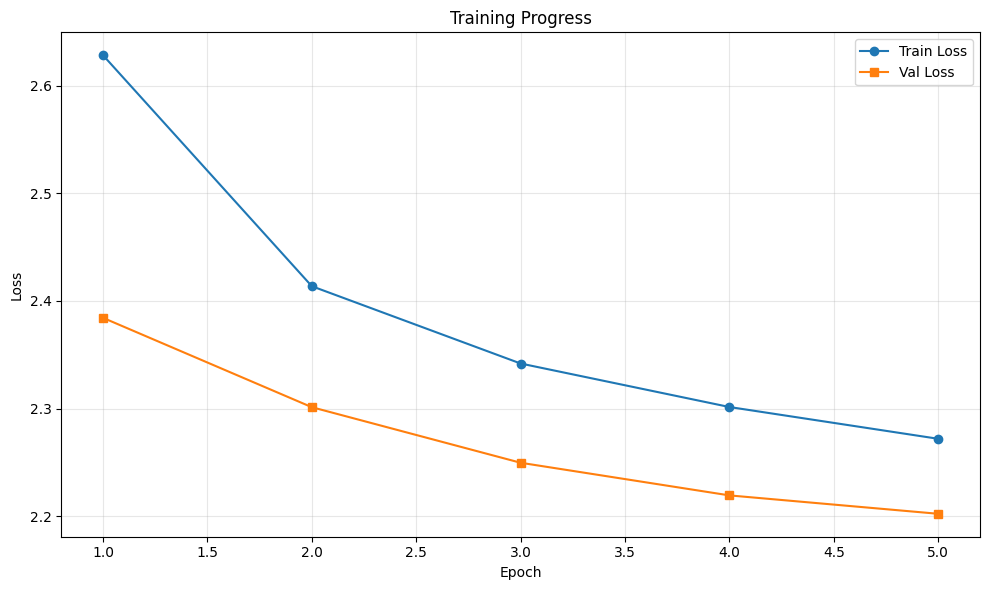

Final train loss: 2.2719
Final val loss: 2.2023


In [23]:
# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")

## Part 12: Generation and Visualization

### Generating Names

Now let's use our trained Transformer to generate new names!

In [24]:
def generate_samples(model, tokenizer, num_samples=10, max_length=20, temperature=1.0):
    """Generate samples from the model."""
    model.eval()
    samples = []
    
    # Start token
    start_idx = tokenizer.get_special_token_idx()
    
    with torch.no_grad():
        for _ in range(num_samples):
            # Start with special token
            idx = torch.tensor([[start_idx]], dtype=torch.long, device=device)
            
            # Generate
            generated = model.generate(idx, max_new_tokens=max_length-1, temperature=temperature)
            
            # Decode
            generated_indices = generated[0].cpu().tolist()
            text = tokenizer.decode(generated_indices)
            
            # Extract name (between special tokens)
            special_token = tokenizer.special_token
            if text.count(special_token) >= 2:
                name = text.split(special_token)[1]
            else:
                name = text.replace(special_token, '')
            
            samples.append(name)
    
    return samples

# Generate samples
print("Generated names (temperature=1.0):")
print("="*40)
samples = generate_samples(model, tokenizer, num_samples=20, temperature=1.0)
for i, name in enumerate(samples, 1):
    print(f"{i:2d}. {name}")

print("\nGenerated names (temperature=0.8 - less random):")
print("="*40)
samples_low_temp = generate_samples(model, tokenizer, num_samples=20, temperature=0.8)
for i, name in enumerate(samples_low_temp, 1):
    print(f"{i:2d}. {name}")

Generated names (temperature=1.0):


 1. elile
 2. kyly
 3. lowyna
 4. havloa
 5. vamiyah
 6. deklerlz
 7. doren
 8. ratilon
 9. adrole
10. ndalena
11. gyle
12. alieah
13. vewer
14. dorenn
15. kayder
16. ale
17. nasori
18. romiceiah
19. kiolen
20. crylen

Generated names (temperature=0.8 - less random):


 1. lillann
 2. janalia
 3. dezlail
 4. mayriya
 5. daylani
 6. camer
 7. kaynny
 8. braynn
 9. manzin
10. cain
11. dyarie
12. hordon
13. jason
14. ideleegh
15. mayan
16. jarellynnn
17. vasil
18. brosta
19. jamiah
20. eisan


### Visualizing Attention After Training

Let's see what attention patterns the model learned!

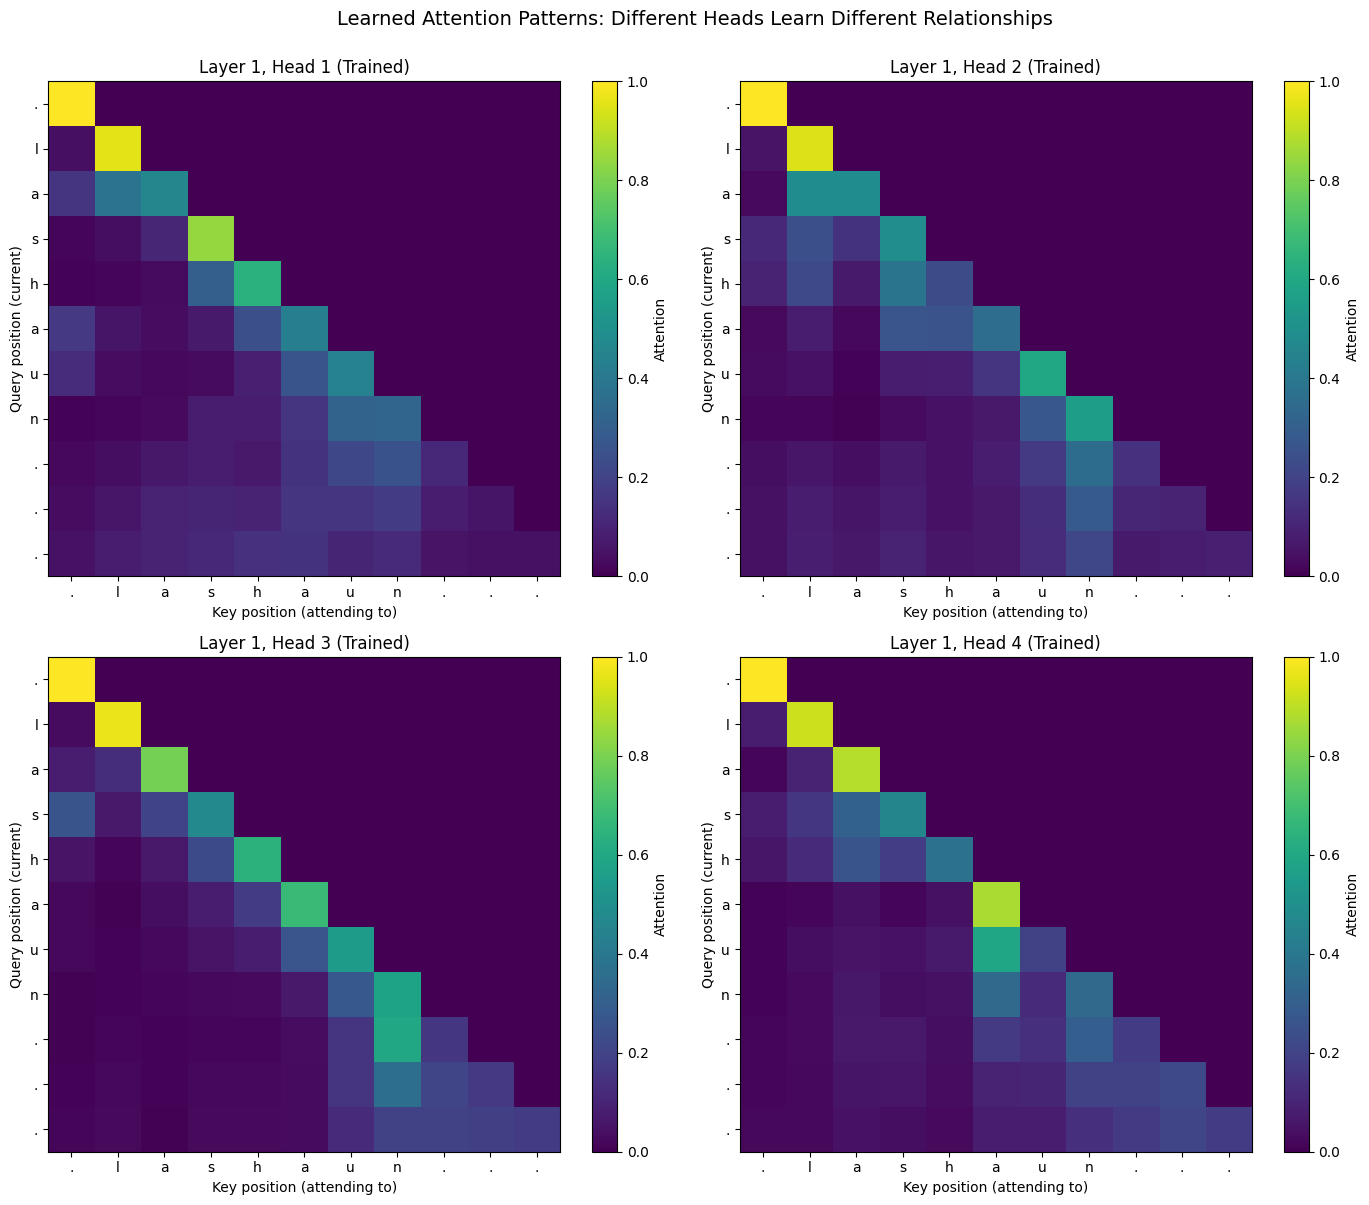


Notice how different heads have learned different attention patterns!
Some heads may focus on:
  - Local context (nearby characters)
  - Previous characters (autoregressive)
  - Specific character relationships


In [25]:
# Hook to capture attention weights
attention_weights_all = []

def attention_hook(module, input, output):
    """Hook to capture attention weights."""
    if isinstance(output, tuple):
        attention_weights_all.append(output[1].detach().cpu())

# Register hooks on attention layers
hooks = []
for block in model.blocks:
    hook = block.attention.register_forward_hook(attention_hook)
    hooks.append(hook)

# Get a sample and run forward pass
model.eval()
sample_x, _ = next(iter(val_loader))
sample_x = sample_x[:1].to(device)  # Take first example
seq_len = sample_x.size(1)
mask = create_causal_mask(seq_len).to(device)

# We need to modify the attention forward to return weights
# Let's do a direct forward pass on the first block
with torch.no_grad():
    # Get embeddings
    x = model.embedding(sample_x)
    x = model.pos_encoding(x)
    
    # Get attention from first block
    x_norm = model.blocks[0].norm1(x)
    _, attn_weights = model.blocks[0].attention(x_norm, mask=mask, return_attention=True)

# Remove hooks
for hook in hooks:
    hook.remove()

# Visualize attention weights from first layer
attn = attn_weights[0].cpu().numpy()  # (num_heads, seq_len, seq_len)
chars = [tokenizer.decode_char(idx.item()) for idx in sample_x[0].cpu()]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for head_idx in range(num_heads):
    ax = axes[head_idx]
    im = ax.imshow(attn[head_idx], cmap='viridis', aspect='auto')
    ax.set_xlabel('Key position (attending to)')
    ax.set_ylabel('Query position (current)')
    ax.set_title(f'Layer 1, Head {head_idx + 1} (Trained)')
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(chars, rotation=0)
    ax.set_yticklabels(chars)
    plt.colorbar(im, ax=ax, label='Attention')

plt.suptitle('Learned Attention Patterns: Different Heads Learn Different Relationships', 
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("\nNotice how different heads have learned different attention patterns!")
print("Some heads may focus on:")
print("  - Local context (nearby characters)")
print("  - Previous characters (autoregressive)")
print("  - Specific character relationships")

## Part 13: Understanding What We Built

### Key Takeaways

Congratulations! You've built a Transformer from scratch. Let's recap the key insights:

#### 1. Self-Attention is the Core Innovation
- Allows every position to attend to every other position
- Parallel processing (unlike RNNs)
- No information bottleneck

#### 2. Multi-Head Attention = Multiple Perspectives
- Different heads learn different relationships
- More expressive than single-head
- Same computational cost!

#### 3. Positional Encodings Add Order
- Attention is permutation-invariant without them
- Sinusoidal patterns encode position at multiple frequencies
- Enable the model to use position information

#### 4. Residuals + LayerNorm = Stable Training
- Residual connections allow gradient flow
- Layer normalization stabilizes activations
- Essential for deep networks

#### 5. Feed-Forward Networks Add Capacity
- Attention aggregates, FFN transforms
- Applied position-wise (independently)
- Adds non-linearity and capacity

### Architecture Summary

```
Input (token IDs)
    ↓
Embedding + Positional Encoding
    ↓
┌─────────────────────────────┐
│   Transformer Block (×N)    │
│                             │
│   x = x + Attention(Norm(x))│
│   x = x + FFN(Norm(x))      │
└─────────────────────────────┘
    ↓
Layer Norm
    ↓
Output Projection
    ↓
Logits (vocabulary probabilities)
```

## Part 14: Experiments to Try

### Understanding Through Experimentation

The best way to build intuition is to experiment! Try these modifications:

#### 1. Architecture Changes
- **More layers**: Change `num_layers` from 4 to 6 or 8
  - What happens to training time?
  - Does performance improve?
  
- **More heads**: Change `num_heads` from 4 to 8
  - Do you get more diverse attention patterns?
  
- **Larger model**: Increase `d_model` from 64 to 128
  - How many more parameters?
  - Better performance?

#### 2. Training Changes
- **Learning rate**: Try 1e-4 or 1e-3
  - Too high → unstable training
  - Too low → slow learning
  
- **More epochs**: Train for 10-20 epochs
  - Does it overfit?
  - When does validation loss stop improving?

#### 3. Generation Changes
- **Temperature**: Try 0.5, 1.0, 1.5
  - Lower → more deterministic, realistic
  - Higher → more random, creative
  
- **Top-k sampling**: Sample from top k most likely tokens
  - Add this to the `generate` method!

#### 4. Ablation Studies
- **No positional encoding**: Comment out `self.pos_encoding(x)`
  - Can the model still learn?
  - How does generation quality change?
  
- **No residual connections**: Remove the `x +` in TransformerBlock
  - Can it train at all?
  - Try training with just 2 layers

- **Single head**: Set `num_heads=1`
  - How much does performance drop?
  - Compare to multi-head version

Try these experiments below!

In [26]:
# Experiment space - try modifications here!

# Example: Train with different temperature
print("Experiment: Different sampling temperatures\n")

for temp in [0.5, 0.8, 1.0, 1.2, 1.5]:
    print(f"Temperature: {temp}")
    print("-" * 40)
    samples = generate_samples(model, tokenizer, num_samples=5, temperature=temp)
    for i, name in enumerate(samples, 1):
        print(f"  {i}. {name}")
    print()

Experiment: Different sampling temperatures

Temperature: 0.5
----------------------------------------


  1. arialia
  2. ana
  3. samari
  4. amian
  5. kayley

Temperature: 0.8
----------------------------------------


  1. kaciell
  2. davidyn
  3. kakland
  4. ki
  5. yisa

Temperature: 1.0
----------------------------------------
  1. triyela
  2. priidina
  3. alis
  4. camiid
  5. yenea

Temperature: 1.2
----------------------------------------


  1. samiyra
  2. yuhseol
  3. khamael
  4. brvione
  5. anidon

Temperature: 1.5
----------------------------------------
  1. dahehitaak
  2. jahlise
  3. alegynn
  4. karti
  5. zuere



## Final Reflections

### What Makes Transformers Powerful?

1. **Parallelization**: All positions processed simultaneously
2. **Long-range dependencies**: Direct connections between any positions
3. **Flexibility**: Same architecture works for many tasks (translation, generation, classification)
4. **Scalability**: Performance improves with more data and compute

### From Here to GPT

You've built the same architecture as GPT! The differences are:
- **Scale**: GPT-3 has 175 billion parameters (vs our ~100k)
- **Data**: Trained on hundreds of billions of tokens
- **Compute**: Thousands of GPUs for weeks
- **Optimizations**: Better initialization, learning rate schedules, etc.

But the **core mechanism** is exactly what you built today!

### Next Steps

To deepen your understanding:
1. Read the original paper: "Attention Is All You Need" (Vaswani et al., 2017)
2. Study GPT: "Language Models are Unsupervised Multitask Learners" (Radford et al., 2019)
3. Explore BERT: "BERT: Pre-training of Deep Bidirectional Transformers" (Devlin et al., 2018)
4. Build a larger model and train on more data!

**Congratulations on building a Transformer from scratch!** 🎉